# Анализ лояльности пользователей Яндекс Афиши
- Автор: Друпп Егор
- Дата: 04.04.2026

Целью данного ИДА является изучение поведения пользователей для того, чтобы определить признаки, позволяющие удерживать клиентов или привлекать новых. По итогу анализа будут предоставлены рекомендации по удержании пользователей.

---
### Подключение к базе данных
Чтобы провести анализ данных, нам необходимо подключится к самой базе данных. Для этого воспользуемся библиотеками `pandas` и `sqlalchemy`.

In [1]:
# Подключим необходимые библиотеки и методы
import pandas as pd
from sqlalchemy import create_engine
import numpy as np

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

# Библиотеки для работы с чувствительнымми данными
from dotenv import load_dotenv
import os

Для того чтобы подключить соединение нужно подготовить параметры для и строку для подключения.

In [2]:
# Подключим секретные данные
load_dotenv()

True

In [3]:
# Формируем строку для подключения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    os.getenv('DB_USER'),
    os.getenv('DB_PWD'),
    os.getenv('DB_HOST'),
    os.getenv('DB_PORT'),
    os.getenv('DB_NAME'),
)

Теперь создадим само подключение.

In [4]:
# Создаем подключение 
engine = create_engine(connection_string)

Далее напишем запрос, вытягивающие необходимые данные для анализа. Здесь уже присутсвует фильтрация по устройствам, с которых был сделан заказ, и типу события.

In [5]:
# Примерный запрос
query = '''
with pre_final_tabel as (
  select *
  from afisha.purchases
  left join afisha.events using(event_id)
  left join afisha.city using(city_id)
  left join afisha.regions using(region_id)
  where device_type_canonical in ('mobile','desktop') and event_type_main != 'фильм'
)
select 
  user_id,
  device_type_canonical,
  order_id,
  created_dt_msk as order_dt,
  created_ts_msk as order_ts,
  currency_code,
  revenue,
  tickets_count,
  extract(DAY from (created_dt_msk - lag(created_dt_msk, 1, null) over (partition by user_id order by created_dt_msk))) as days_since_prev,
  event_id,
  event_name_code as event_name,
  event_type_main,
  service_name,
  region_name,
  city_name
from pre_final_tabel
order by user_id
'''

Теперь создадим датафрейм и выгрузим в него результат SQL-запроса

In [6]:
# Выгрузим запрос в датафрейм
df = pd.read_sql_query(query, con=engine)

---
### Цели и задачи проекта

* Познакомится с данными
* Сделать необходимую предобработку данных
* Произвести исследовательский анализ данных
* Предоставить наглядную статистику и рекомендации

### Описание данных
После выгрузки данных из SQL в датафрейм вошли следующие данные:
- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

### Содержимое проекта

1. Знакомство с данными
2. Предобработка данных
3. Создание профиля пользователя
4. Исследовательский анализ данных
5. Итоговый вывод и рекомендации

---

## 1. Знакомство с данными

Выведем несколько первых строк датафрейма и общую информацию.

In [7]:
# Первые строки датафрейма
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [8]:
# Вывод информации по столбцам
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

В данном датафрейме 290611 записей и 15 полей. Рассмотрим корректность типов данных.
* Тип `object` имеют поля `user_id`, `device_type_canonical`, `currency_code`, `event_name`, `event_type_main`, `service_name`, `region_name` и `city_name`. Вполне корректный тип данных для полей, которые должны содержать текстовые данные.
* Тип `datetime64[ns]` имеют поля `order_dt` и `order_ts`. Также корректный тип данных для полей, хранящих дату и время совершения заказов.
* Тип `float64` для полей `revenue` и `days_since_prev` также является приемлемым. Однако пропуски в `days_since_prev` и понимание того, что в поле должны хранится целочисленные данные, позволят в будущем поработать над переопределением типа.
* Тип `int64` для полей `order_id`, `tickets_count` и `event_id` не вызывает вопросов. Но в целях оптимизации можно привести к меньшему разряду поле `tickets_count`.

Пропуски обнаружеы в поле `days_since_prev`, что объясняется отсутвием предыдущего заказа у каждого первого заказа пользователя. Пропуски нужно отсавить.

---

##  2. Предобработка данных

Для начала приведем выручку к одной валюте - российскому рублю. Вослпользуемся датасетом с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год.

In [9]:
# Выгружаем информацию о курсе валют
tenge_rub_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [10]:
# Выведем информацию о датафрейме
tenge_rub_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Для того чтобы привести выручку к общей валюте, необходимо сопоставлять месяц создания заказа с положением курса тенге на тот месяц. Первым делом переопределим тип для даты.

In [11]:
# Переопределяем тип данных
tenge_rub_df['data'] = pd.to_datetime(tenge_rub_df['data'])

Теперь создадим функцию, которую с помощью метода `apply()` применим к датафрейму.

In [12]:
# Сама функция 
def tenge_to_rub(row):
    if row['currency_code'] == 'rub':
        return row['revenue']
    rate_row = tenge_rub_df[tenge_rub_df['data'] == row['order_dt']]
    if not rate_row.empty:
        curs = rate_row['curs'].iloc[0]    
        nominal = rate_row['nominal'].iloc[0]  
        return row['revenue'] * curs / nominal

In [13]:
# Создаем новый столбец с выручкой рублями
df['revenue_rub'] = df.apply(tenge_to_rub, axis=1)

---

### Обработка пропусков
Пропуски были обнаружены в поле `days_since_prev`, но, поскольку дальше понадобится только среднее значение между покупками то, пропуски можно оставить.

---

### Работа с типами данных
Приведем поля `days_since_prev` и `tickets_count` к меньшим разрядностям.

In [14]:
# Переопределяем поле с количеством дней между заказами
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='float')

# Переопределяем поле с количеством биоетом
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')

---
### Обработка дубликатов

Сначала проверим некоторые категориальные поля на наличие неявнях дубликатов.

In [15]:
# Проверим тип устройства
df.device_type_canonical.unique()

array(['mobile', 'desktop'], dtype=object)

In [16]:
# Проверим тип мероприятия
df.event_type_main.unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

In [17]:
# Избавимся от дубликатов
df = df.drop_duplicates(subset=['user_id', 'device_type_canonical',
       'currency_code', 'revenue', 'tickets_count', 
       'event_id', 'event_name', 'event_type_main', 'service_name',
       'region_name', 'city_name', 'revenue_rub'])

Ошибок или опечаток выявлено не было. Теперь проверим данные на явные дубликаты.

In [18]:
# Поверим наличие явных дубликатов
df.duplicated().sum()

np.int64(0)

Дубликаты не выявлены.

---

### Обработка аномальных значений

Для того чтобы опредедлить выбросы построим "ящик с усами" для полей `tickets_count` и `revenue_rub`.

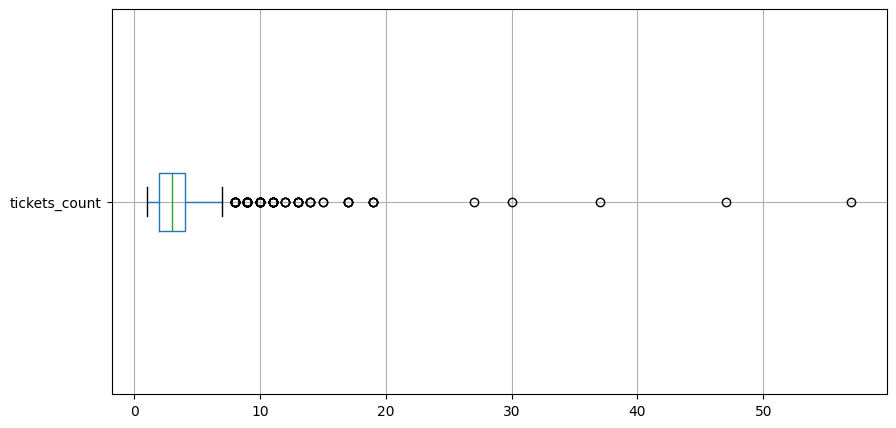

In [19]:
# Строим диаграмму размаха для билетов
df.boxplot(
    column='tickets_count',
    vert=False,
    grid=True,
    figsize=(10, 5)
)
plt.show()

Такие выбросы могут обуславливаться тем, что билеты могут брать не только отдельные люди, но и организации (школы, интернаты и др.), что не является чем-то аномальным.

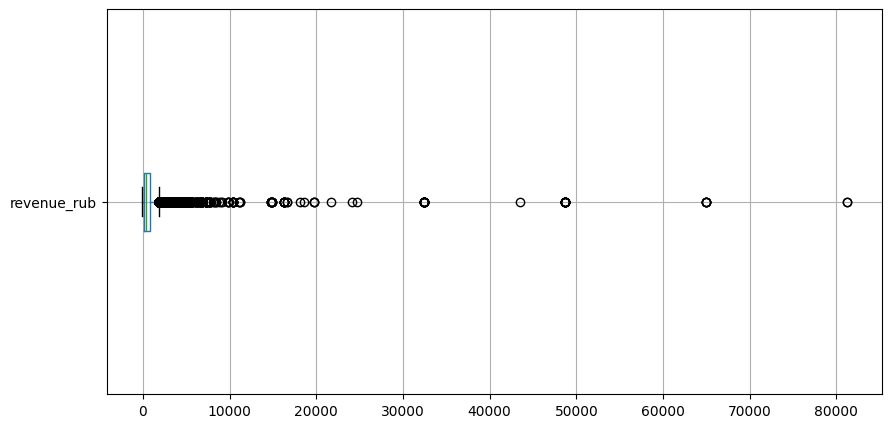

In [20]:
# Строим диаграмму размаха для выручки
df.boxplot(
    column='revenue_rub',
    vert=False,
    grid=True,
    figsize=(10, 5)
)
plt.show()

Поскольку были выявлены аномальные значения, отсортируем датафрейм по 99-му процентилю по полю `revenue_rub`.

In [21]:
# Отчищаем датасет от выбросов
df = df[df['revenue_rub'] <= df['revenue_rub'].quantile(0.99)]

В результате предобработки было сделано следующее:
* Оптимизированы поля `tickets_count` и `days_since_prev`;
* Добавлено новое поле `revenue_rub` чтобы привести выручку к одному курсу;
* Были удалены строки с аномальными значениями по полю `revenue_rub`.

Проверим долю удаленных строк.

In [22]:
# Разделим количество строк полученного датафрейма на количество строк исходного
1 - df.shape[0] / pd.read_sql_query(query, con=engine).shape[0]

0.22939599671037914

Получился почти процент от изначального количества, однако это не повлияет на дальнейший анализ. Все в порядке, так что можно идти дальше.

---

## 3. Создание профиля пользователя


Создадим датафрейм с профилем пользователя, чтобы на основе этого понять почему пользовотели остаются или покидают портал. Для начала отсортируем по дате создания заказа.

In [23]:
# Сортируем по датет создания
df = df.sort_values(by='order_dt')

Поскольку после группировке порядок записей в датафрейме не меняется, можем использовать метод `fisrt`, чтобы определять признаки при вервом заказе пользователя.

In [24]:
# Сохраняем профиль пользователя 
user_profile = df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'min'),
    last_order_dt=('order_dt', 'max'),
    device_type=('device_type_canonical', 'first'),
    region=('region_name', 'first'),
    service=('service_name', 'first'),
    event_type=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    avg_revenue=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_since_prev=('days_since_prev', 'mean')
).reset_index()

Добивам поля-флаги для категоризации по количеству заказов. Для этого напишем функции для метода `apply()`.

In [25]:
# Создаем функцию для поля is_two
def is_two_method(total_orders):
    return True if total_orders >= 2 else False

# Создаем функцию для поля is_five
def is_five_method(total_orders):
    return True if total_orders >= 5 else False

In [26]:
# Применим с помощью aaply и сохраним в новые поля
user_profile['is_two'] = user_profile['total_orders'].apply(is_two_method)
user_profile['is_five'] = user_profile['total_orders'].apply(is_five_method)

Посмотрим насколько датасет репрезентативен, подсчитав некоторые статистические показктели.

In [27]:
# Воспользуемся меьтодом describe для определения большинства статистических показателей
user_profile.describe()

,first_order_dt,last_order_dt,total_orders,avg_revenue,avg_tickets,avg_days_since_prev
count,21840,21840,21840.000000,21840.000000,21840.000000,12931.000000
mean,2024-08-10 00:29:20.439560448,2024-09-18 06:34:29.010989056,10.253938,542.331119,2.743048,18.386688
min,2024-06-01 00:00:00,2024-06-01 00:00:00,1.000000,-10.770000,1.000000,0.000000
25%,2024-06-25 00:00:00,2024-08-25 00:00:00,1.000000,215.612500,2.000000,2.209965
50%,2024-08-09 00:00:00,2024-10-03 00:00:00,2.000000,472.964167,2.750000,10.600000
75%,2024-09-23 00:00:00,2024-10-22 00:00:00,4.000000,755.896667,3.000000,24.500000
max,2024-10-31 00:00:00,2024-10-31 00:00:00,7254.000000,2607.162135,11.000000,148.000000
std,NaN,NaN,89.287805,423.855415,0.906869,23.462723


In [28]:
# Количество пользователей (количество записей в датафрейме)
user_profile.shape[0]

21840

In [29]:
# Доли пользователей по количеству заказов 
user_profile['is_two'].mean() # Для двух и более

np.float64(0.5901556776556777)

In [30]:
# Доли пользователей по количеству заказов 
user_profile['is_five'].mean() # Для пяти и более

np.float64(0.24386446886446886)

По полученным статистическим показателям можно сказать следующее:
* У какого-то пользователя количество заказов просто зашкаливает.
* В поле с выручкой за заказ присутсвует орицательное значение.

Рассмотрим поля `total_orders` и `revenue` более детально. Для этого построим диаграммы размаха и дальше решим что делать с выбросами.

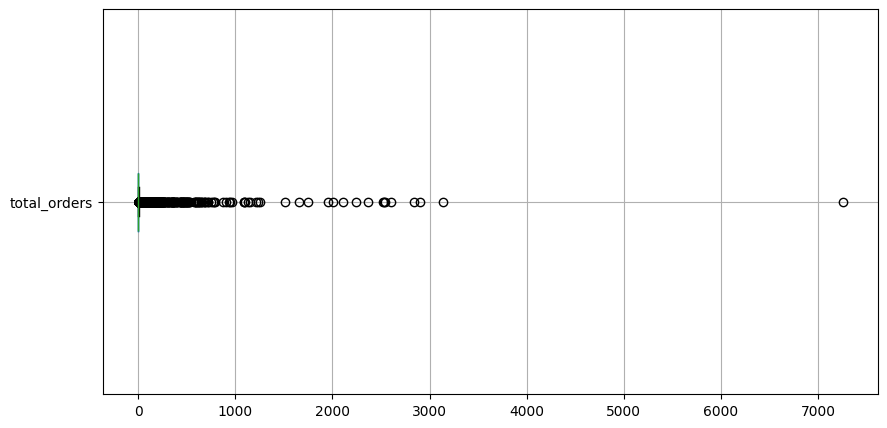

In [31]:
# Строим диаграмму размаха для общего количества заказов для пользователя
user_profile.boxplot(
    column='total_orders',
    vert=False,
    grid=True,
    figsize=(10, 5)
)
plt.show()

In [32]:
# Найдем долю пользователей с выбросами
user_profile[user_profile['total_orders'] > user_profile['total_orders'].quantile(0.99)].shape[0] / user_profile.shape[0]

0.009935897435897435

In [33]:
# Познакомимся с такими пользователями
user_profile[user_profile['total_orders'] > user_profile['total_orders'].quantile(0.99)].head()

,user_id,first_order_dt,last_order_dt,device_type,region,service,event_type,total_orders,avg_revenue,avg_tickets,avg_days_since_prev,is_two,is_five
106,01370a0e9c1a7d5,2024-06-01,2024-10-31,mobile,Лесодальний край,Прачечная,театр,123,527.467886,2.723577,1.221311,True,True
137,019fa401ddb00aa,2024-06-01,2024-10-31,mobile,Горицветская область,Билеты без проблем,театр,522,476.214693,2.745211,0.272553,True,True
188,024dc5236465850,2024-06-01,2024-10-31,mobile,Североярская область,Реестр,концерты,877,550.660208,2.834664,0.167808,True,True
235,02ea4583333f064,2024-06-01,2024-10-31,mobile,Широковская область,Билеты без проблем,другое,2243,563.326323,2.747214,0.059322,True,True
317,03dfd23ba7c058e,2024-06-03,2024-10-31,mobile,Североярская область,Билеты в руки,другое,250,546.269760,2.732000,0.586345,True,True


In [34]:
# Сохраним таких пользователей 
anomaly_users = user_profile[user_profile['total_orders'] > user_profile['total_orders'].quantile(0.99)]

Чтобы определится, что делать с этими выбросами, посмотрим, возможно ли за все время существования аккаунта такого пользователя сделать все эти заказы. Для этого перемножим поля `avg_days_since_prev` и `total_orders`, чтобы узнать время затраченное на создание заказов и сравним с разницей между первым и последним заказом пользователя.

In [35]:
# Создаем датасет с нужными значениями
analize_user_profile = pd.DataFrame({
    'days_between': (anomaly_users['last_order_dt'] - anomaly_users['first_order_dt']).dt.days,
    'during_ordering': anomaly_users['total_orders'] * anomaly_users['avg_days_since_prev']
})

# Создадим функцию чтобы заполнить поле флаг
def set_flag(row):
    return True if row['days_between'] >= row['during_ordering'] else False

# Создадим новое поле
analize_user_profile['flag'] = analize_user_profile.apply(set_flag, axis=1)

# Проверим сколько записей являются корректными
analize_user_profile['flag'].sum()

np.int64(208)

Выяснилось, что таких записей 123 штуки. Скорее всего это какие-то технические ошибки или что-то в этом роде. Однако остальные строки корректны, поскольку таким пользователем может являться бот или другая система, следовательно, такие строки тоже не подойдут для анализа. Ведь чтобы определить стратегию по удержании клиетов, нужны сами клиенты, эти данные можно убрать из профилей пользователей, учитывая и тот факт, что такие записи составляют процент от всех пользователей.

In [36]:
# Отфильтруем записи по 99-ому процентилю по количеству заказов
user_profile = user_profile[user_profile['total_orders'] <= user_profile['total_orders'].quantile(0.99)]

Теперь разберемся с полем `avg_revenue`. Для этого найдем записи где средняя выручка с заказа отрицательна.

In [37]:
# Найдем долю таких записей
user_profile[user_profile['avg_revenue'] < 0].shape[0] / user_profile.shape[0]

0.0007399528280072145

Очевидно, что от таких записей можно спойоно избавиться, поскольку это никак не повляиет на исследование.

In [38]:
# Отфильтруем по средней выручке
user_profile = user_profile[user_profile['avg_revenue'] >= 0]

In [39]:
# Проверим сколько строк было удалено во время фильтрации
1 - user_profile.shape[0] / df['user_id'].nunique()

0.01066849816849813

В результате фильтрации был убран процент от изначального количества записей, что не повлияет на исследование, следовательно можно идти дальше.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу




Проанализируем количество пользователей в разрезе первого устройства, мероприятия, региона проведения и билетного оператора, чтобы понять, существуют ли выраженные точки входа.

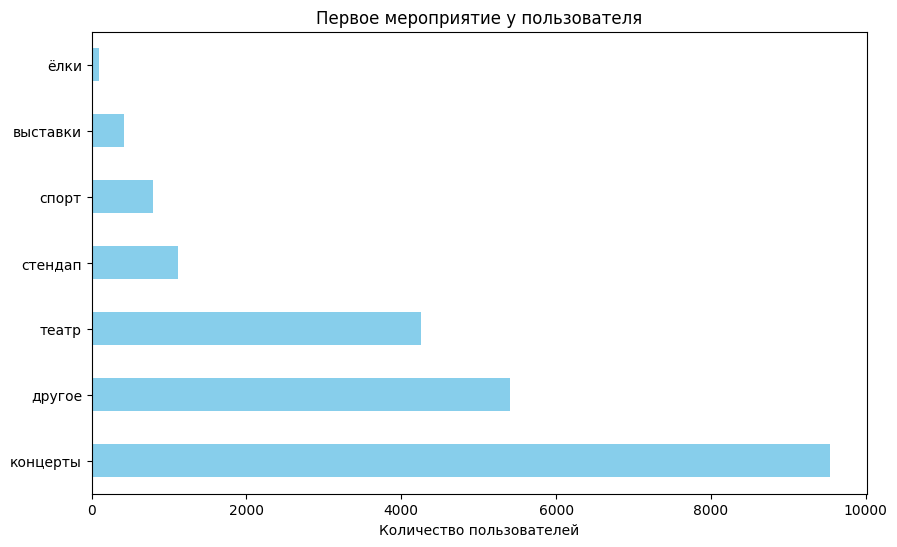

In [40]:
# Строим диаграмму для пользователей в разрезе типа первого мероприятия
user_profile['event_type'].value_counts().sort_values(ascending=False).plot(
    kind='barh',
    color='skyblue',
    ylabel='',
    xlabel='Количество пользователей',
    title='Первое мероприятие у пользователя',
    figsize=(10,6)
)
plt.show()

In [41]:
# Доли таких пользователей
user_profile['event_type'].value_counts().sort_values(ascending=False) / user_profile.shape[0]

event_type
концерты    0.441200
другое      0.250012
театр       0.196788
стендап     0.051604
спорт       0.036840
выставки    0.019114
ёлки        0.004443
Name: count, dtype: float64

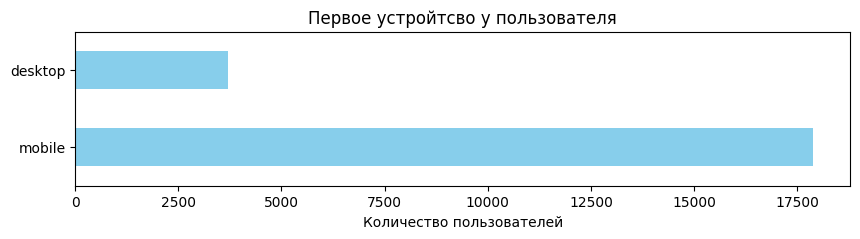

In [42]:
# Строим диаграмму для пользователей в разрезе типа устройства
user_profile['device_type'].value_counts().sort_values(ascending=False).plot(
    kind='barh',
    color='skyblue',
    ylabel='',
    xlabel='Количество пользователей',
    title='Первое устройтсво у пользователя',
    figsize=(10,2)
)
plt.show()

In [43]:
# Доли таких пользователей
user_profile['device_type'].value_counts().sort_values(ascending=False) / user_profile.shape[0]

device_type
mobile     0.828065
desktop    0.171935
Name: count, dtype: float64

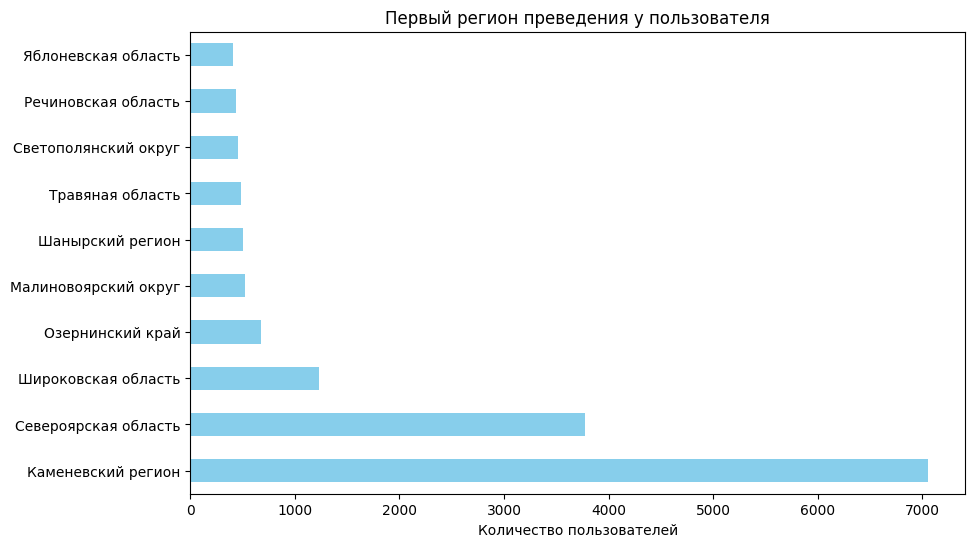

In [44]:
# Строим диаграмму для пользователей в разрезе первого региона
user_profile['region'].value_counts().head(10).sort_values(ascending=False).plot(
    kind='barh',
    color='skyblue',
    ylabel='',
    xlabel='Количество пользователей',
    title='Первый регион преведения у пользователя',
    figsize=(10,6)
)
plt.show()

In [45]:
# Доли таких пользователей
user_profile['region'].value_counts().head(10).sort_values(ascending=False) / user_profile.shape[0]

region
Каменевский регион      0.326653
Североярская область    0.174851
Широковская область     0.056926
Озернинский край        0.031240
Малиновоярский округ    0.024437
Шанырский регион        0.023187
Травяная область        0.022539
Светополянский округ    0.021197
Речиновская область     0.020271
Яблоневская область     0.019114
Name: count, dtype: float64

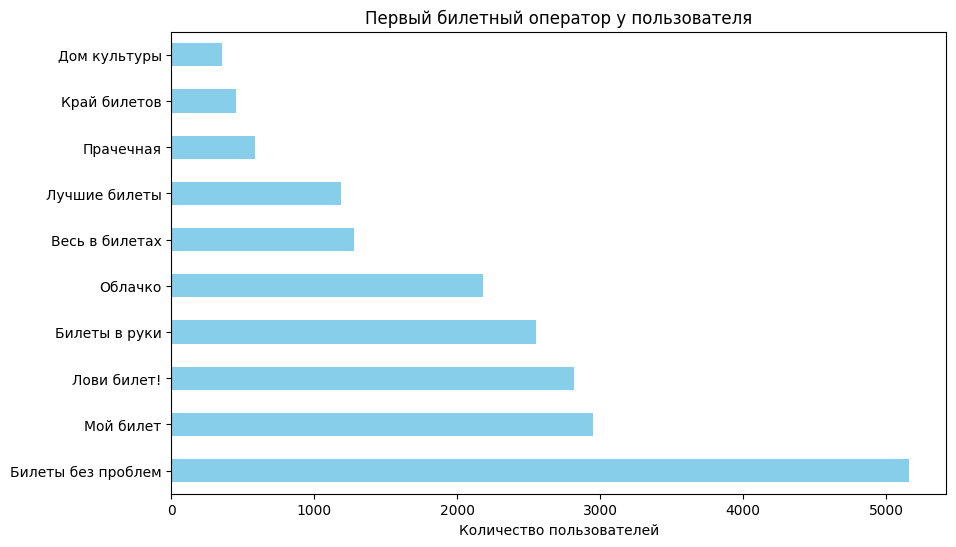

In [46]:
# Строим диаграмму для пользователей в разрезе первого билетного оператора
user_profile['service'].value_counts().sort_values(ascending=False).head(10).plot(
    kind='barh',
    color='skyblue',
    ylabel='',
    xlabel='Количество пользователей',
    title='Первый билетный оператор у пользователя',
    figsize=(10,6)
)
plt.show()

In [47]:
# Доли таких пользователей
user_profile['service'].value_counts().head(10).sort_values(ascending=False) / user_profile.shape[0]

service
Билеты без проблем    0.238904
Мой билет             0.136622
Лови билет!           0.130467
Билеты в руки         0.117925
Облачко               0.100893
Весь в билетах        0.059147
Лучшие билеты         0.054797
Прачечная             0.026982
Край билетов          0.021012
Дом культуры          0.016245
Name: count, dtype: float64

На основе полученных данных можно сказать следующее:
* Большинство пользователей впервые идут на `концерты`, в `театры` и `другое`;
* Свой первый заказ пользователь чаще совершает с мобильного устройства;
* Чаще всего пользоваетль свой первый заказ делает из `Каменевского региона` или `Североярской области`;
* Самые популярные площадки для заказа первого билета: `Билеты без проблем`, `Мой билет`, `Лови билет!`, `Билеты в руки` и `Облачко`.

Таким образом, популярность этих категорий является точками входа, то есть новые пользователи чаще выбирают именно эти категории.

---



Теперь проверим возвраты пользователей. Для этого проанализируем доли пользователей совершившие повторный заказ.

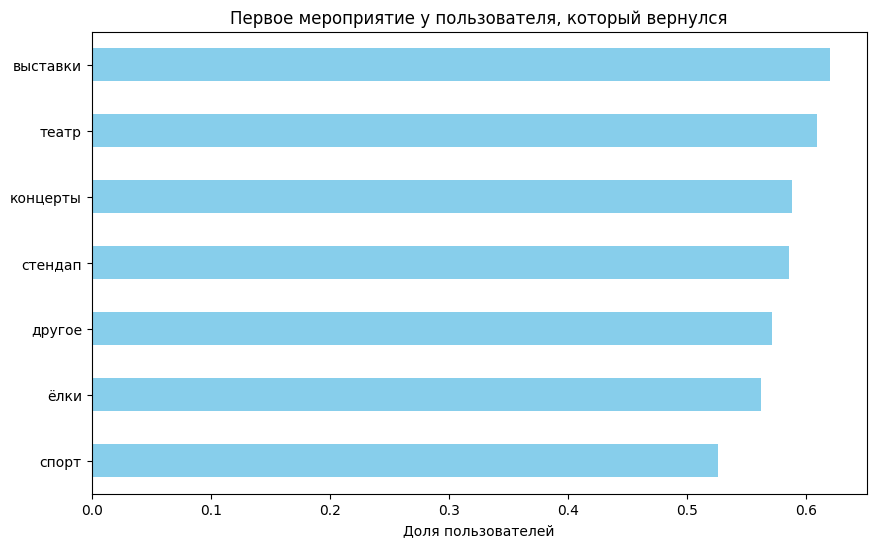

In [48]:
user_profile.groupby('event_type')['is_two'].mean().sort_values().plot(
    kind='barh',
    color='skyblue',
    ylabel='',
    xlabel='Доля пользователей',
    title='Первое мероприятие у пользователя, который вернулся',
    figsize=(10,6)
)
plt.show()

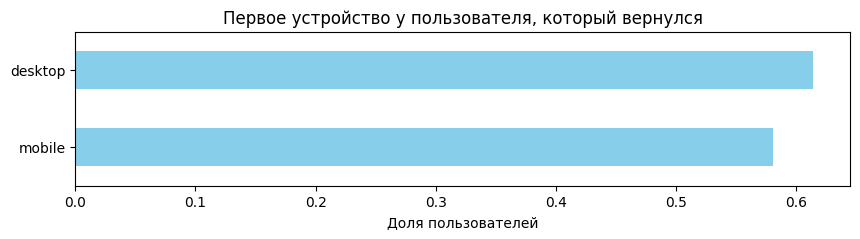

In [49]:
user_profile.groupby('device_type')['is_two'].mean().sort_values().plot(
    kind='barh',
    color='skyblue',
    ylabel='',
    xlabel='Доля пользователей',
    title='Первое устройство у пользователя, который вернулся',
    figsize=(10,2)
)
plt.show()

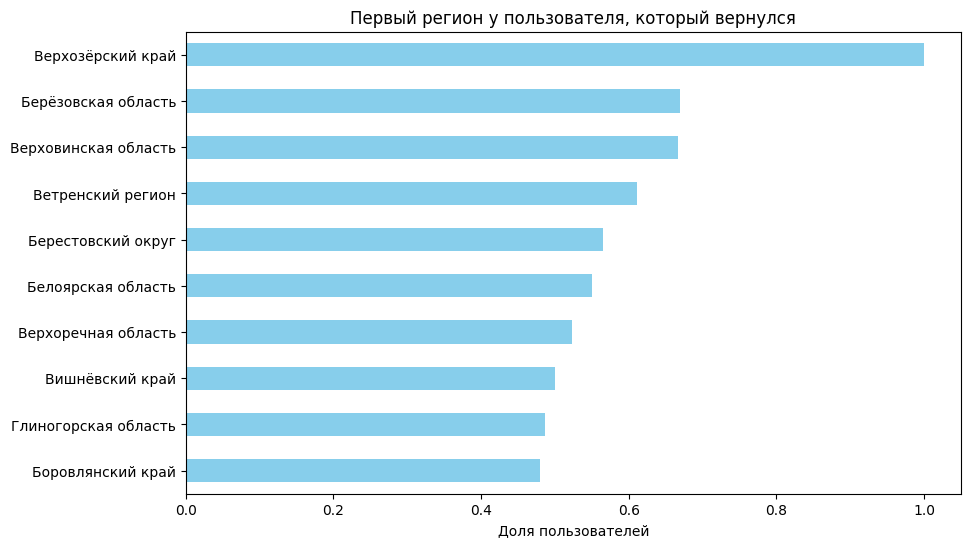

In [50]:
user_profile.groupby('region')['is_two'].mean().head(10).sort_values().plot(
    kind='barh',
    color='skyblue',
    ylabel='',
    xlabel='Доля пользователей',
    title='Первый регион у пользователя, который вернулся',
    figsize=(10,6)
)
plt.show()

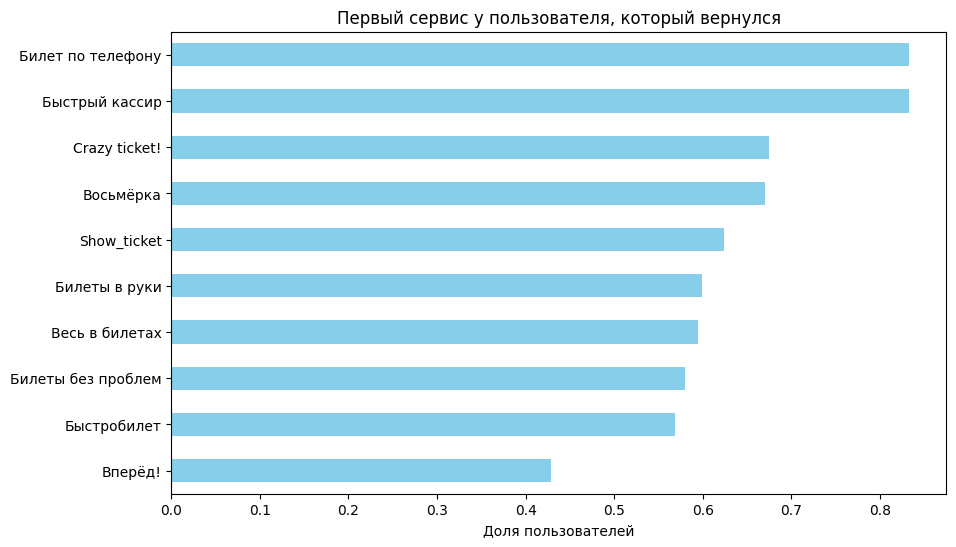

In [51]:
user_profile.groupby('service')['is_two'].mean().head(10).sort_values().plot(
    kind='barh',
    color='skyblue',
    ylabel='',
    xlabel='Доля пользователей',
    title='Первый сервис у пользователя, который вернулся',
    figsize=(10,6)
)
plt.show()

Сюдя по полученным данным, можно сказать следующее:
* Тип первого устройства и мероприятия не имеют каких либо точек входа, поскольку примерно половина рользователей в каждом сегмента предпочитает вернуться;
* Пользователи, воспользовавшиеся сервисами `Быстрый кассир` и `Билет по телефону`, чаще предпочитают сделать повторный заказ;
* Мероприятия, билеты на которые пользователи впервые приобрели в `Верхозёрском крае`, также чаще совершают повторныц заказ.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Гипотезу 1** можно опровергнуть, поскольку доли пользователей, совершивших повторный заказ, все коляблятся около половины.

Также **гипотеза 2** является ложной, поскольку регионы с высокой долей пользователей, совершивших повторный заказ, не попадают в топ-10 регионов по количеству пользователей.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа


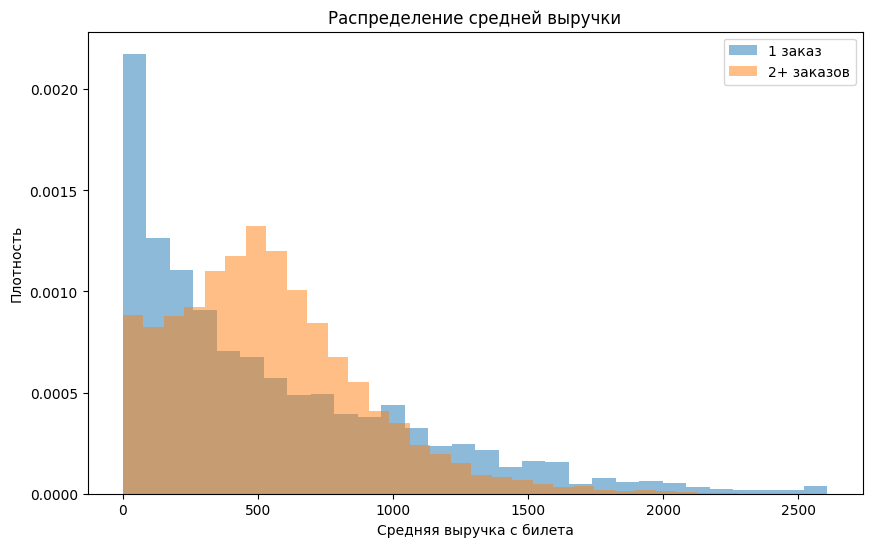

In [52]:
plt.figure(figsize=(10, 6))
plt.hist(user_profile[user_profile['total_orders'] == 1]['avg_revenue'], 
         bins=30, alpha=0.5, density=True, label='1 заказ')
plt.hist(user_profile[user_profile['total_orders'] >= 2]['avg_revenue'], 
         bins=30, alpha=0.5, density=True, label='2+ заказов')
plt.xlabel('Средняя выручка с билета')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки')
plt.legend()
plt.show()

По гистограмме видно, что пик пользователей, совершивших один заказ, приходится на среднюю выручку в районе 0-200 рублей. Пик пользователей, совершивишич повторный заказ, приходится на среднюю выручку в районе 400-600 рублей.

В группах наблюдаются различия:
* Пики пользователей приходятся на разные средние выручки;
* Изучая среднюю вуручку до 1000 рублей, наблюдаем рост лояльности пользователей.
* У "одноразовых" пользователей большой хвост с права, что говорит о негативной корреляции лояльности с очень высокой средней выручкой.

---



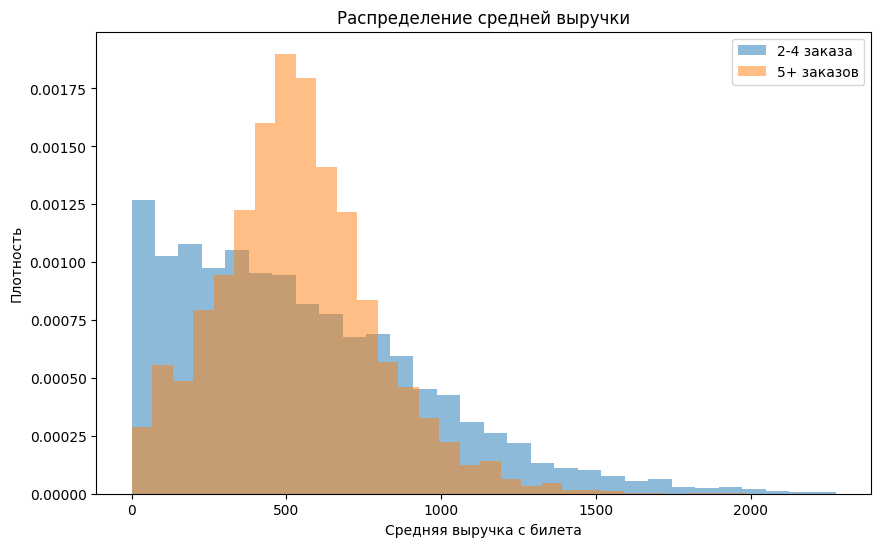

In [68]:
plt.figure(figsize=(10, 6))
plt.hist(user_profile[(user_profile['is_two'])&(~user_profile['is_five'])]['avg_revenue'], 
         bins=30, alpha=0.5, density=True, label='2-4 заказа')
plt.hist(user_profile[user_profile['is_five']]['avg_revenue'], 
         bins=30, alpha=0.5, density=True, label='5+ заказов')
plt.xlabel('Средняя выручка с билета')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки')
plt.legend()
plt.show()

В этих двух группах различаются пики пользователей, а именно: пик пользователей, которые совершают 5 и более заказов, находится в районе 400-800 рублей средней выручки. Также наблюдается нелояльность клиентов, сделавших дешевые и слишком дорогие заказы.

---


In [54]:
# Сделаем поле категорию
user_profile['tickets_group'] = pd.cut(user_profile['avg_tickets'], bins=[1,2,3,5,np.inf], labels=['от 1 до 2','от 2 до 3','от 3 до 5','от 5 и более'])

In [55]:
# Найдем общее число пользователей
user_profile['tickets_group'].value_counts().sort_values(ascending=False)

tickets_group
от 2 до 3       9963
от 3 до 5       5181
от 1 до 2       4949
от 5 и более     178
Name: count, dtype: int64

In [56]:
user_profile.groupby('tickets_group')['is_two'].mean().sort_values(ascending=False)

C:\Users\kuzmi\AppData\Local\Temp\ipykernel_7744\208737435.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_profile.groupby('tickets_group')['is_two'].mean().sort_values(ascending=False)


tickets_group
от 2 до 3       0.726187
от 3 до 5       0.589655
от 1 до 2       0.458072
от 5 и более    0.235955
Name: is_two, dtype: float64

Судя по полученным данным, можно увидеть, что данные распределены сконцетрировано вокруг среднего количества билетов в заказе от 2 до 3. Чем популярней категория, тем выше доля пользователей, совершающих повторную покупку.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки




Проверим взаимосвязь днем недели первого заказаи лояльностью пользователя.

In [57]:
# Создадим список дней недели
day_of_week_names = ['понедельник','вторник','среда','четверг','пятница','суббота','воскресенье']

# Выделим день недели
user_profile['day_of_the_week'] = user_profile['first_order_dt'].dt.strftime('%A')

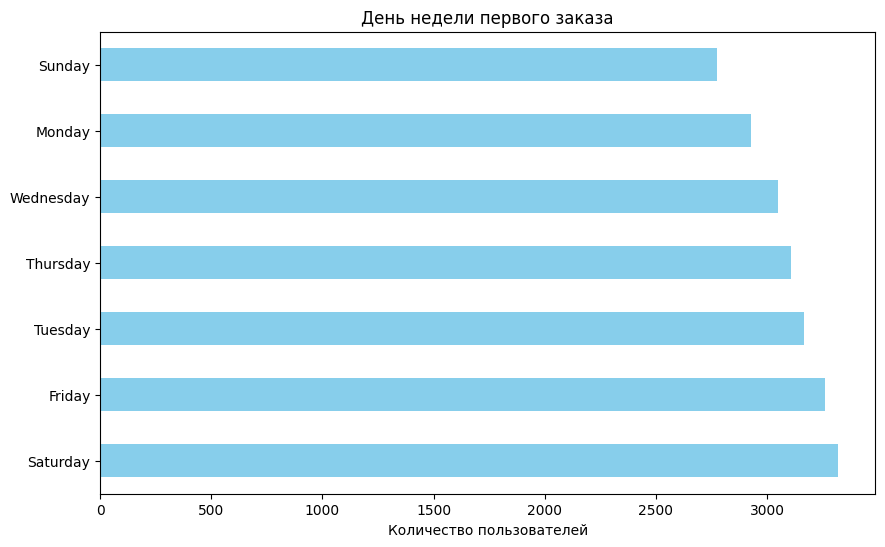

In [58]:
# Создаем диаграмму для общего количества пользователей
user_profile['day_of_the_week'].value_counts().sort_values(ascending=False).plot(
    kind='barh',
    color='skyblue',
    ylabel='',
    xlabel='Количество пользователей',
    title='День недели первого заказа',
    figsize=(10,6)
)
plt.show()

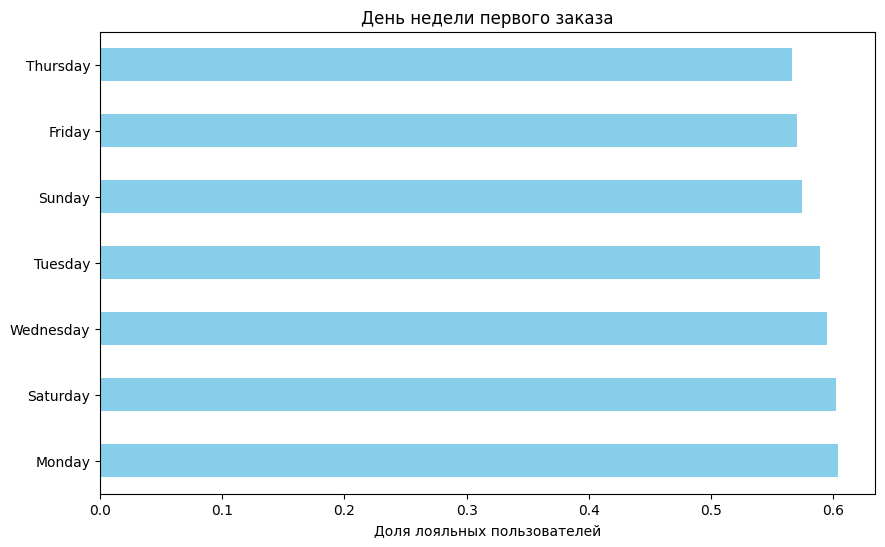

In [59]:
# Строим диаграмму для долей лояльных пользователей
user_profile.groupby('day_of_the_week')['is_two'].mean().sort_values(ascending=False).plot(
    kind='barh',
    color='skyblue',
    ylabel='',
    xlabel='Доля лояльных пользователей',
    title='День недели первого заказа',
    figsize=(10,6)
)
plt.show()

Согласно полученным результатам, день недели практически не влияет на лояльность пользователя.

---




Теперь изучим средний интервал между заказами групп пользователей и это влияние на удержание клиента.

In [60]:
# Среднее между закзами пользователей совершивших 2-4 заказа
user_profile[(user_profile['total_orders'] >= 2)&(user_profile['total_orders'] <= 4)]['avg_days_since_prev'].mean()

np.float32(23.179955)

In [61]:
# Среднее между закзами пользователей совершивших 5 и более заказов
user_profile[user_profile['total_orders'] >= 5]['avg_days_since_prev'].mean()

np.float32(11.9805155)

Можно заметить, что чем больше активность пользователя, тем меньше среднее время между закзами.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя


In [62]:
# Создаем матрицу корреляции
correlation_matrix = user_profile[['total_orders','region','avg_days_since_prev','avg_tickets','device_type','event_type','avg_revenue','service']].phik_matrix()

interval columns not set, guessing: ['total_orders', 'avg_days_since_prev', 'avg_tickets', 'avg_revenue']


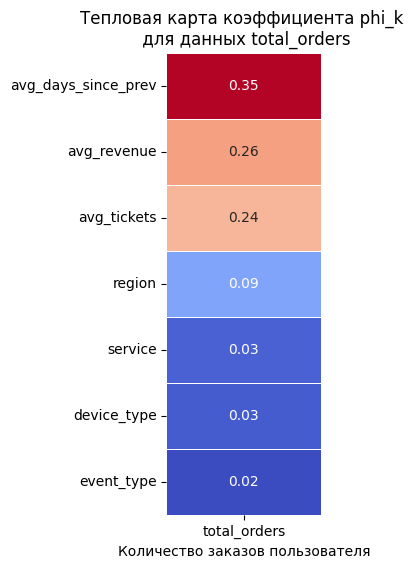

In [63]:
# Отфильтруем только столбец с категориями и не включим их в таблицу
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)

# Строим тепловую карту
plt.figure(figsize=(2, 6))
sns.heatmap(data_heatmap,
            annot=True,
            fmt='.2f', 
            cmap='coolwarm', 
            linewidths=0.5, 
            cbar=False 
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных total_orders')
plt.xlabel('Количество заказов пользователя')
plt.show()

Значения практически нулевые, следовательно разделим пользователей на сегменты и по этим сегментам проведем корреляционный анализ.

In [64]:
# Сделаем новое  поле с сешментами пользователей
user_profile['user_segment'] = pd.cut(user_profile['total_orders'], bins=[1, 2, 5, np.inf], right=False, labels=['1 заказ', '2-4 заказа', '5 и более'])

In [65]:
# Создаем матрицу корреляции
correlation_matrix = user_profile[['user_segment','region','avg_days_since_prev','avg_tickets','device_type','event_type','avg_revenue','service']].phik_matrix()

interval columns not set, guessing: ['avg_days_since_prev', 'avg_tickets', 'avg_revenue']


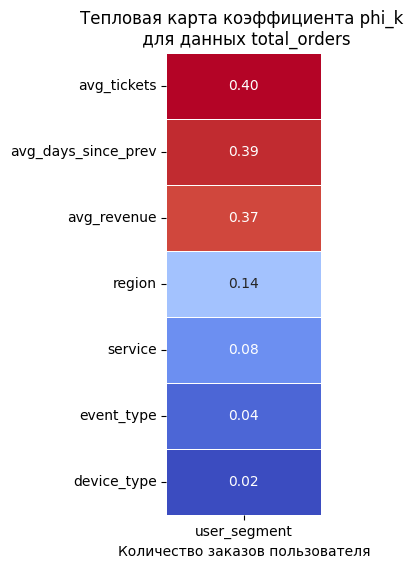

In [66]:
# Отфильтруем только столбец с категориями и не включим их в таблицу
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'user_segment'][['user_segment']].sort_values(by='user_segment', ascending=False)

# Строим тепловую карту
plt.figure(figsize=(2, 6))
sns.heatmap(data_heatmap,
            annot=True,
            fmt='.2f', 
            cmap='coolwarm', 
            linewidths=0.5, 
            cbar=False 
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных total_orders')
plt.xlabel('Количество заказов пользователя')
plt.show()

Как и было выявлено на предыдущих этапах анализа активность пользователя имеет, хоть и слабую, связь с количеством билетов, средней выручкой за заказ и средним количеством дней между заказами.

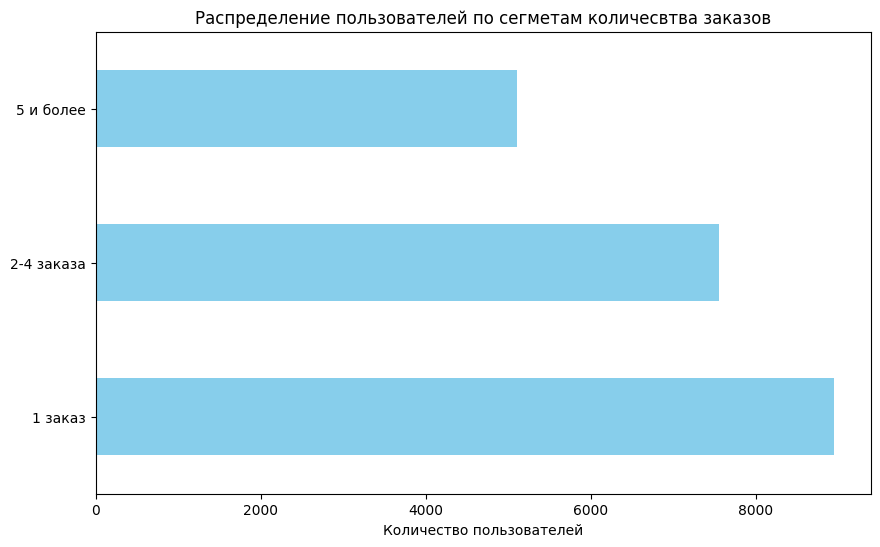

In [67]:
# Проверим как распределены пользователи по количесиву заказов
user_profile['user_segment'].value_counts().sort_values(ascending=False).plot(
    kind='barh',
    color='skyblue',
    ylabel='',
    xlabel='Количество пользователей',
    title='Распределение пользователей по сегметам количесвтва заказов',
    figsize=(10,6)
)
plt.show()

Можно заметить, что пользователей, которые возвращались на площадку около 60%, что говорит о хорошей перспективе удержания клиентов.

### 5. Общий вывод и рекомендации


Информация о данных и предобработке:
* Исходные данные: 290 611 записей о покупках из базы данных Яндекс Афиши за 2024 год
* Фильтрация: исключены заказы с устройств, отличных от mobile/desktop, и мероприятия типа «фильм»
* Валюта: выручка приведена к российским рублям с использованием курса тенге
* Очистка: удалены выбросы по полю revenue_rub (99-й процентиль), что составило ~1% данных
* Итоговая выборка: 21 854 уникальных пользователя с профилями, агрегированными по ключевым метрикам

Признаки первого заказа, влияющие на возврат:
* Тип мероприятия: пользователи, начавшие с концертов, чаще возвращаются (44.2% выборки, доля повторных покупок выше).
* Тип устройства: 82.7% пользователей начали с мобильных устройств, но тип устройства не показывает значимой связи с лояльностью.
* Регион: Каменевский регион (32.8%) и Североярская область (17.5%) — основные точки входа, но география не является сильным предиктором удержания.
* Билетный оператор: не выявлено существенных различий в лояльности между операторами.

Средняя выручка и количество билетов:
* Пользователи с 1 заказом имеют пик средней выручки в диапазоне 0–200 руб., тогда как лояльные пользователи (2+ заказа) — в диапазоне 400–600 руб.
* Наблюдается негативная корреляция: слишком низкая (<200 руб.) или слишком высокая (>1000 руб.) средняя выручка связана с меньшей вероятностью повторной покупки.
* Сегмент «2–3 билета в заказе» наиболее массовый (9 930 пользователей) и показывает наивысшую долю повторных покупок (74.3%).

Временные характеристики:
* День недели первой покупки: не оказывает статистически значимого влияния на вероятность возврата.
* Интервал между заказами: пользователи с 5+ заказами делают покупки в среднем каждые 9.9 дней, тогда как пользователи с 2–4 заказами — каждые 21.3 дня. Чем короче интервал, тем выше лояльность.

Корреляционный анализ (phi_k):
* Наиболее сильные связи с количеством заказов (total_orders) показали:
* `avg_tickets` (среднее количество билетов): слабая положительная связь.
* `avg_revenue` (средняя выручка): слабая положительная связь.
* `avg_days_since_prev`: слабая отрицательная связь (чем меньше дней между заказами, тем больше общее число заказов).
Категориальные признаки (`region`, `device_type`, `event_type`, `service`) показали близкие к нулю значения корреляции.

---

**Рекомендации**

Фокус на сегменты с высоким потенциалом удержания:
* Пользователи, совершившие первый заказ на концерты или театр, со средним чеком 400–600 руб. и 2–3 билетами в заказе.
* Для этой группы эффективны персонализированные рекомендации похожих мероприятий и программа лояльности с накопительными бонусами.

Работа с «одноразовыми» пользователями:
* Пользователи с одним заказом и низким средним чеком (<200 руб.) требуют дополнительных триггеров: приветственные скидки на следующую покупку, напоминания о предстоящих событиях в их регионе.

Оптимизация коммуникации по времени:
* Учитывая, что лояльные пользователи покупают каждые ~10 дней, настроить автоматические уведомления за 7–10 дней после последнего заказа с персональными предложениями.

Мониторинг аномалий:
* Регулярно отслеживать пользователей с экстремально высоким количеством заказов (возможные боты или корпоративные аккаунты) для очистки аналитических выборок.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**